In [4]:
import pyspark

In [5]:
spark = SparkSession.builder \
    .appName("StockTweetForecasting") \
    .config("spark.pyspark.python", "/home/hduser/pyspark_env/bin/python") \
    .config("spark.pyspark.driver.python", "/home/hduser/pyspark_env/bin/python") \
    .config("spark.executorEnv.PYSPARK_PYTHON", "/home/hduser/pyspark_env/bin/python") \
    .getOrCreate()

26/06/03 14:43:04 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, count, avg
from pyspark.sql.functions import lower, regexp_replace, trim, length

spark = SparkSession.builder.appName("StockTweetForecasting").getOrCreate()

stock_tweets = spark.read.csv("hdfs:///stocks/raw_data/stocktweet.csv",header=True,inferSchema=True)

stock_tweets = stock_tweets.withColumn("date", to_date(col("date"), "dd/MM/yyyy"))

stock_tweets.printSchema()
stock_tweets.show(10, truncate=False)

root
 |-- id: string (nullable = true)
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)

+------------------------------------------------------------------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|id                                                                |date      |ticker|tweet                                                                                                                                      |
+------------------------------------------------------------------+----------+------+-------------------------------------------------------------------------------------------------------------------------------------------+
|100001                                                            |2020-01-01|AMZN  |$AMZN Dow futures up by 100 points already 🥳                                        

In [7]:
import re
import html
import unicodedata
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def clean_text(text):

    if text is None:
        return ""

    
    text = str(text) # Convert to string
    text = html.unescape(text) # Fix HTML entities
    text = unicodedata.normalize("NFKD", text) # Normalize unicode
    text = text.encode("ascii", "ignore").decode("ascii") # Remove corrupted unicode/emojis
    text = text.lower()  # Lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text) # Remove URLs
    text = re.sub(r"\$[A-Za-z]+", " ", text) # Remove ticker symbols
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text) # Remove mentions
    text = re.sub(r"#", "", text) # Remove hashtags symbol only
    text = re.sub(r"\d+", " ", text) # Remove numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text) # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # Remove extra spaces
    return text

In [8]:
text_udf = udf(clean_text, StringType())

cleaned_df = stock_tweets.withColumn(
    "clean_text",
    text_udf(col("tweet"))
)

selected_tickers = ["ABNB", "AMZN", "NKE", "GOOGL", "NFLX"]

cleaned_df = cleaned_df.filter(
    col("ticker").isin(selected_tickers)
)

cleaned_df.select("ticker", "clean_text").show(30, truncate=False)

cleaned_df.select(
    "ticker",
    "clean_text"
).show(30, truncate=False)

+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ticker|clean_text                                                                                                                                                                                              |
+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|AMZN  |dow futures up by points already                                                                                                                                                                        |
|AMZN  |who ever shorted today will be deported from us if you are immigrants                                                                                   

In [9]:
#pip install vaderSentiment

In [10]:
ABNB = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/ABNB.csv",
    header=True,
    inferSchema=True
)

AMZN = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/AMZN.csv",
    header=True,
    inferSchema=True
)

NKE = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/NKE.csv",
    header=True,
    inferSchema=True
)

GOOGL = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/GOOGL.csv",
    header=True,
    inferSchema=True
)

NFLX = spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/NFLX.csv",
    header=True,
    inferSchema=True
)

In [11]:
spark.read.csv(
    "hdfs:///stocks/raw_data/stockprice/ABNB.csv",
    header=True,
    inferSchema=True
).show(5)

+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|      Date|              Open|             High|               Low|             Close|         Adj Close|  Volume|
+----------+------------------+-----------------+------------------+------------------+------------------+--------+
|2020-12-10|             146.0|            165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|
|2020-12-11| 146.5500030517578|            151.5|135.10000610351562|            139.25|            139.25|26980800|
|2020-12-14|             135.0|135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|
|2020-12-15|126.69000244140625|127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|
|2020-12-16|125.83000183105469|            142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|
+----------+------------------+-----------------+------------------+----

In [12]:
from pyspark.sql.functions import col, to_date

ABNB = ABNB.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
AMZN = AMZN.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
NKE = NKE.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
GOOGL = GOOGL.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
NFLX = NFLX.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

In [13]:
from pyspark.sql.functions import lit

ABNB = ABNB.withColumn("ticker", lit("ABNB"))
AMZN = AMZN.withColumn("ticker", lit("AMZN"))
NKE = NKE.withColumn("ticker", lit("NKE"))
GOOGL = GOOGL.withColumn("ticker", lit("GOOGL"))
NFLX = NFLX.withColumn("ticker", lit("NFLX"))

In [14]:
stock_prices = ABNB.union(AMZN) \
                   .union(NKE) \
                   .union(GOOGL) \
                   .union(NFLX)

stock_prices.show(300)

+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|   Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672| 70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25| 26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0| 16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781| 10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406| 20409600|  ABNB|


In [15]:
final_data = stock_prices

final_data.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [16]:
tweets = spark.read.csv(
    "hdfs:///stocks/raw_data/stocktweet.csv",
    header=True,
    inferSchema=True
)

tweets.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



In [17]:
tweets.printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



In [18]:
stock_prices.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- ticker: string (nullable = false)



In [19]:
final_data = stock_prices
final_data.show()

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

# EDA

In [20]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, to_date, count, isnan, when, avg, min, max, stddev

spark = SparkSession.builder.appName("Stock_EDA").getOrCreate()

26/06/03 14:43:54 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [21]:
base_path = "hdfs:///stocks/raw_data/stockprice/"

ABNB = spark.read.csv(base_path + "ABNB.csv", header=True, inferSchema=True).withColumn("ticker", lit("ABNB"))
AMZN = spark.read.csv(base_path + "AMZN.csv", header=True, inferSchema=True).withColumn("ticker", lit("AMZN"))
NKE = spark.read.csv(base_path + "NKE.csv", header=True, inferSchema=True).withColumn("ticker", lit("NKE"))
GOOGL = spark.read.csv(base_path + "GOOGL.csv", header=True, inferSchema=True).withColumn("ticker", lit("GOOGL"))
NFLX = spark.read.csv(base_path + "NFLX.csv", header=True, inferSchema=True).withColumn("ticker", lit("NFLX"))

In [22]:
stock_prices = ABNB.unionByName(AMZN) \
                   .unionByName(NKE) \
                   .unionByName(GOOGL) \
                   .unionByName(NFLX)

stock_prices.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [23]:
stock_prices.printSchema()
stock_prices.describe().show()
stock_prices.count()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- ticker: string (nullable = false)



26/06/03 14:44:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------+
|summary|              Open|              High|               Low|             Close|         Adj Close|              Volume|ticker|
+-------+------------------+------------------+------------------+------------------+------------------+--------------------+------+
|  count|              1031|              1031|              1031|              1031|              1031|                1031|  1031|
|   mean|189.35049027776856| 192.4516494077577|186.32689610508086|189.52595670239424|188.61383644200203|  3.78168935014549E7|  NULL|
| stddev|152.79033750091668|155.63455600221457| 149.9919498788437|152.99703797462874| 153.4885667234985|4.3088415122295536E7|  NULL|
|    min| 52.81850051879883| 53.34550094604492| 50.44350051879883| 52.70650100708008| 52.70650100708008|             1144000|  ABNB|
|    max|   567.97998046875| 575.3699951171875|             541.0| 55

1031

In [24]:
stock_prices = stock_prices.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

stock_prices.select("Date", "ticker").show(10)

+----------+------+
|      Date|ticker|
+----------+------+
|2020-12-10|  ABNB|
|2020-12-11|  ABNB|
|2020-12-14|  ABNB|
|2020-12-15|  ABNB|
|2020-12-16|  ABNB|
|2020-12-17|  ABNB|
|2020-12-18|  ABNB|
|2020-12-21|  ABNB|
|2020-12-22|  ABNB|
|2020-12-23|  ABNB|
+----------+------+
only showing top 10 rows



In [25]:
missing_values = stock_prices.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in stock_prices.columns
])

missing_values.show()

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
|   0|   0|   0|  0|    0|        0|     0|     0|
+----+----+----+---+-----+---------+------+------+



In [26]:
ABNB = spark.read.csv("hdfs:///stocks/raw_data/stockprice/ABNB.csv", header=True, inferSchema=True)
AMZN = spark.read.csv("hdfs:///stocks/raw_data/stockprice/AMZN.csv", header=True, inferSchema=True)
NKE = spark.read.csv("hdfs:///stocks/raw_data/stockprice/NKE.csv", header=True, inferSchema=True)
GOOGL = spark.read.csv("hdfs:///stocks/raw_data/stockprice/GOOGL.csv", header=True, inferSchema=True)
NFLX = spark.read.csv("hdfs:///stocks/raw_data/stockprice/NFLX.csv", header=True, inferSchema=True)

In [27]:
from pyspark.sql.functions import lit

ABNB = ABNB.withColumn("ticker", lit("ABNB"))
AMZN = AMZN.withColumn("ticker", lit("AMZN"))
NKE = NKE.withColumn("ticker", lit("NKE"))
GOOGL = GOOGL.withColumn("ticker", lit("GOOGL"))
NFLX = NFLX.withColumn("ticker", lit("NFLX"))

stock_prices = ABNB.unionByName(AMZN) \
                   .unionByName(NKE) \
                   .unionByName(GOOGL) \
                   .unionByName(NFLX)

stock_prices.show(10)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|  Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+
|2020-12-10|             146.0|             165.0|            141.25| 144.7100067138672| 144.7100067138672|70447500|  ABNB|
|2020-12-11| 146.5500030517578|             151.5|135.10000610351562|            139.25|            139.25|26980800|  ABNB|
|2020-12-14|             135.0| 135.3000030517578|125.16000366210938|             130.0|             130.0|16966100|  ABNB|
|2020-12-15|126.69000244140625| 127.5999984741211|             121.5|124.80000305175781|124.80000305175781|10914400|  ABNB|
|2020-12-16|125.83000183105469|             142.0|124.91000366210938|137.99000549316406|137.99000549316406|20409600|  ABNB|
|2020-12

In [28]:
#pip install setuptools pandas

In [29]:
final_pd = stock_prices.toPandas()

In [30]:
final_pd = final_data.toPandas()

final_pd.head()

,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,2020-12-10,146.000000,165.000000,141.250000,144.710007,144.710007,70447500,ABNB
1,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,ABNB
2,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,ABNB
3,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,ABNB
4,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,ABNB


In [31]:
print(final_pd.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'ticker'],
      dtype='str')


In [32]:
final_pd.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
ticker       0
dtype: int64

In [33]:
final_pd["ticker"].value_counts()

ticker
AMZN     254
NKE      254
GOOGL    254
NFLX     254
ABNB      15
Name: count, dtype: int64

In [34]:
print("Start Date:", final_pd["Date"].min())
print("End Date:", final_pd["Date"].max())

Start Date: 2019-12-31
End Date: 2020-12-31


In [35]:
import pandas as pd

final_pd["Date"] = pd.to_datetime(final_pd["Date"])
df = final_pd.copy()

df = df.sort_values(["ticker", "Date"])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,2020-12-10,146.000000,165.000000,141.250000,144.710007,144.710007,70447500,ABNB
1,2020-12-11,146.550003,151.500000,135.100006,139.250000,139.250000,26980800,ABNB
2,2020-12-14,135.000000,135.300003,125.160004,130.000000,130.000000,16966100,ABNB
3,2020-12-15,126.690002,127.599998,121.500000,124.800003,124.800003,10914400,ABNB
4,2020-12-16,125.830002,142.000000,124.910004,137.990005,137.990005,20409600,ABNB


In [36]:
df.isnull().sum()
df.describe()
df["ticker"].value_counts()

ticker
AMZN     254
GOOGL    254
NFLX     254
NKE      254
ABNB      15
Name: count, dtype: int64

In [37]:
#This line helps to make columns for each company
tickers = ["ABNB", "AMZN", "GOOGL", "NKE", "NFLX"]

company_data = {}

for ticker in tickers:
    company_data[ticker] = df[df["ticker"] == ticker].copy()
    company_data[ticker] = company_data[ticker].sort_values("Date")

company_data

{'ABNB':          Date        Open        High         Low       Close   Adj Close  \
 0  2020-12-10  146.000000  165.000000  141.250000  144.710007  144.710007   
 1  2020-12-11  146.550003  151.500000  135.100006  139.250000  139.250000   
 2  2020-12-14  135.000000  135.300003  125.160004  130.000000  130.000000   
 3  2020-12-15  126.690002  127.599998  121.500000  124.800003  124.800003   
 4  2020-12-16  125.830002  142.000000  124.910004  137.990005  137.990005   
 5  2020-12-17  143.000000  152.449997  142.669998  147.050003  147.050003   
 6  2020-12-18  150.449997  159.000000  150.300003  157.300003  157.300003   
 7  2020-12-21  155.309998  172.000000  145.110001  163.020004  163.020004   
 8  2020-12-22  170.000000  174.970001  161.050003  163.190002  163.190002   
 9  2020-12-23  162.813995  168.250000  155.500000  158.009995  158.009995   
 10 2020-12-24  159.160004  162.789993  154.112000  154.839996  154.839996   
 11 2020-12-28  158.600006  163.639999  147.520004  149.

In [38]:
#pip install matplotlib

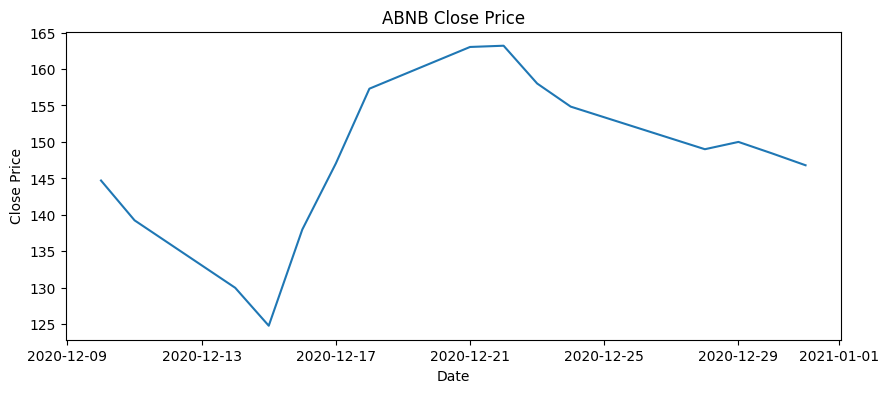

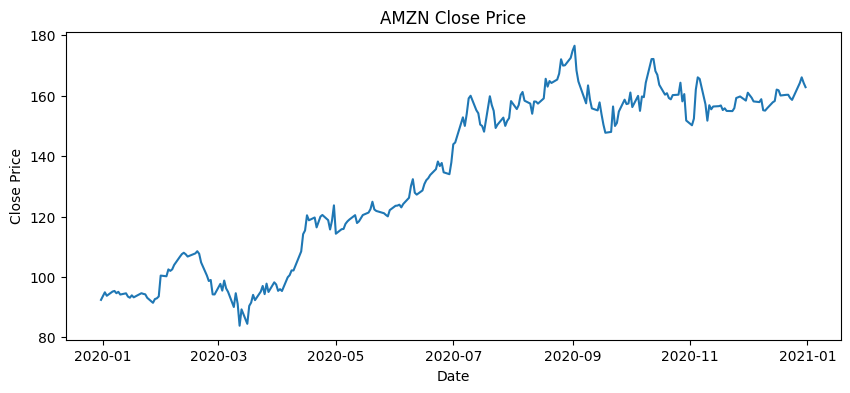

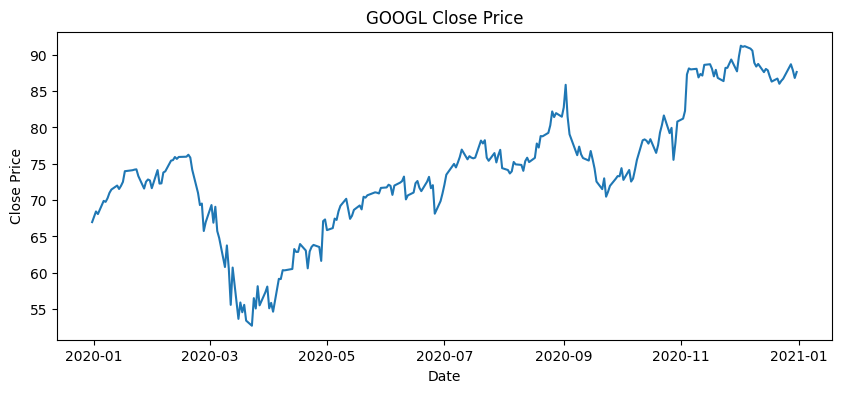

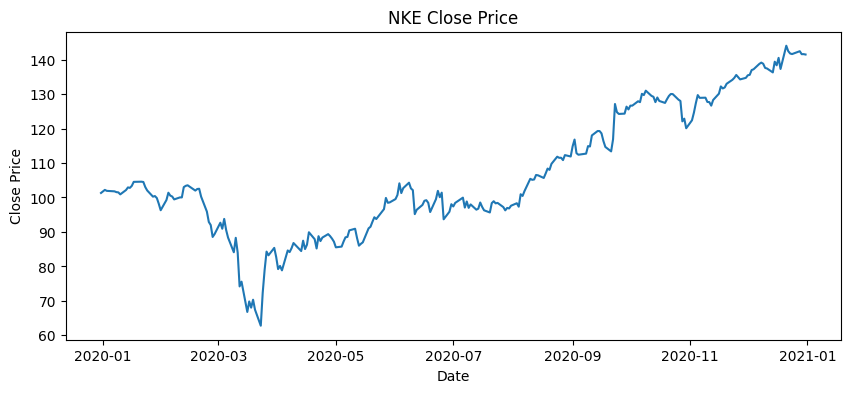

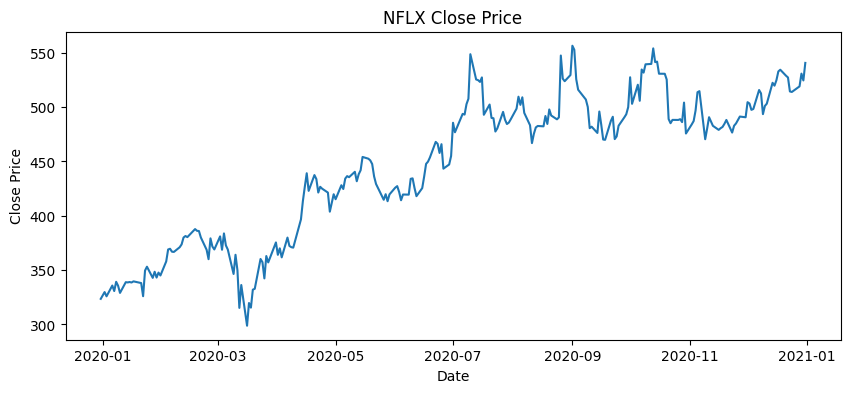

In [39]:
import matplotlib.pyplot as plt

for ticker in tickers:
    temp = company_data[ticker]

    plt.figure(figsize=(10, 4))
    plt.plot(temp["Date"], temp["Close"])
    plt.title(f"{ticker} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()